# Praso Credit Risk Prediction Models
## Phase 1: Environment Setup & Data Loading

available_continuous = [col for col in continuous_cols if col in df_aplicacao.columns]
print("\nContinuous Variables - Summary Statistics:")
if available_continuous and not df_aplicacao.empty:
    print(df_aplicacao[available_continuous].describe().round(3))
else:
    print("  - No continuous columns available or application dataset is empty.")
This notebook implements Phase 1 of the credit risk prediction project:
- Load application data (credito_aplicacao_clientes_final.csv)
if CONFIG['target_column'] in df_aplicacao.columns and not df_aplicacao.empty:
    default_rate = df_aplicacao[CONFIG['target_column']].mean() * 100
    print(f"\nOverall Default Rate: {default_rate:.2f}%")
else:
    default_rate = 0.0
    print(f"\nOverall Default Rate: target column '{CONFIG['target_column']}' missing or dataset empty")
- Prepare datasets for exploratory analysis

if CONFIG['target_column'] in df_aplicacao.columns and not df_aplicacao.empty:
    print(f"\nDefault Distribution:")
    print(df_aplicacao[CONFIG['target_column']].value_counts())
    print(f"Default value counts (%):\n{(df_aplicacao[CONFIG['target_column']].value_counts(normalize=True) * 100).round(2)}")
else:
    print("\nDefault Distribution: target column missing or dataset empty.")

## 1. Environment Setup and Dependencies

In [66]:
# Import required Python packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Initialize dataframes so this setup cell can run independently
df_aplicacao = pd.DataFrame()
df_pedidos = pd.DataFrame()

if not df_aplicacao.empty:
    null_summary = pd.DataFrame({
        'Column': df_aplicacao.columns,
        'Null Count': df_aplicacao.isnull().sum().values,
        'Null %': (df_aplicacao.isnull().sum() / len(df_aplicacao) * 100).round(2).values
    }).sort_values('Null %', ascending=False)
    print(null_summary.to_string(index=False))
else:
    null_summary = pd.DataFrame(columns=['Column','Null Count','Null %'])
    print("  - No application data available to compute null summaries.")

# Define project paths (robust detection of data folder)
# Determine current working directory and prefer a local 'data' folder
cwd = Path.cwd().resolve()
# If running from the notebooks/ folder, cwd is usually project root; otherwise try parent
if (cwd / 'data').exists() or (cwd / 'dataset').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists() or (cwd.parent / 'dataset').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd
# Prefer 'data' directory name, but fall back to 'dataset' if needed
if (PROJECT_ROOT / 'data').exists():
    DATA_DIR = PROJECT_ROOT / 'data'
elif (PROJECT_ROOT / 'dataset').exists():
    DATA_DIR = PROJECT_ROOT / 'dataset'
else:
    DATA_DIR = PROJECT_ROOT / 'data'  # default (may not exist)

# Raw inputs live in dataset/; processed outputs go to data/
if (PROJECT_ROOT / 'dataset').exists():
    INPUT_DIR = PROJECT_ROOT / 'dataset'
else:
    INPUT_DIR = DATA_DIR
OUTPUT_DIR = PROJECT_ROOT / 'data'

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nPython version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

  - No application data available to compute null summaries.
Project root: /Users/esdrasalbino/Documents/university/machine-learning/project_praso
Data directory: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data
Input directory: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/dataset
Output directory: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data

Python version: 3.11.11 (main, Dec  3 2024, 17:20:40) [Clang 16.0.0 (clang-1600.0.26.4)]
Pandas version: 2.3.3
NumPy version: 2.3.4
Timestamp: 2026-05-20 20:57:46


## 2. Load Inputs for Phase 1

Load the two main datasets:
- **Application Data**: Client information at signup (demographics, Serasa credit, iFood/Google presence)
- **Behavioral Data**: Purchase history (orders, values, payment delays)

In [67]:
# Load application data (client information at signup)
aplicacao_path = INPUT_DIR / 'credito_aplicacao_clientes_final.csv'
try:
    df_aplicacao = pd.read_csv(aplicacao_path, encoding='utf-8')
    print(f"✓ Application data loaded successfully")
    print(f"  Shape: {df_aplicacao.shape}")
    print(f"  Columns: {list(df_aplicacao.columns)}")
except FileNotFoundError:
    print(f"✗ File not found: {aplicacao_path}")
    print(f"  Please ensure credito_aplicacao_clientes_final.csv is in {INPUT_DIR}")
    df_aplicacao = pd.DataFrame()  # safe fallback to avoid NameError later
except Exception as e:
    print(f"✗ Error loading application data: {e}")
    df_aplicacao = pd.DataFrame()

print("\n" + "="*80 + "\n")

# Load behavioral data (purchase history)
comportamental_path = INPUT_DIR / 'credito_comportamental_pedidos_final.csv'
try:
    df_pedidos = pd.read_csv(comportamental_path, encoding='utf-8')
    
    def interval_to_midpoint(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float, np.integer, np.floating)):
            return float(value)
        text = str(value).strip()
        if text.startswith(('(', '[')) and text.endswith((')', ']')) and ',' in text:
            bounds = text[1:-1].split(',')
            if len(bounds) == 2:
                try:
                    lower = float(bounds[0].strip())
                    upper = float(bounds[1].strip())
                    return (lower + upper) / 2
                except ValueError:
                    pass
        return pd.to_numeric(value, errors='coerce')
    
    for interval_col in ['valor', 'atraso']:
        if interval_col in df_pedidos.columns and df_pedidos[interval_col].dtype == 'object':
            converted = df_pedidos[interval_col].map(interval_to_midpoint)
            if converted.notna().any():
                df_pedidos[interval_col] = converted
                print(f"  Converted {interval_col} interval bins to numeric midpoints")
    print(f"✓ Behavioral data loaded successfully")
    print(f"  Shape: {df_pedidos.shape}")
    print(f"  Columns: {list(df_pedidos.columns)}")
except FileNotFoundError:
    print(f"✗ File not found: {comportamental_path}")
    print(f"  Please ensure credito_comportamental_pedidos_final.csv is in {INPUT_DIR}")
    df_pedidos = pd.DataFrame()  # safe fallback to avoid NameError later
except Exception as e:
    print(f"✗ Error loading behavioral data: {e}")
    df_pedidos = pd.DataFrame()

✓ Application data loaded successfully
  Shape: (3000, 19)
  Columns: ['id_cliente', 'uf', 'municipio', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente', 'cnae_codigo', 'capital_social', 'idade_cnpj', 'serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_credores', 'serasa_socio_tem_negativacao', 'ifood_contagem_avaliacoes', 'ifood_faixa_preco', 'google_maps_avaliacao', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website', 'inadimplente']


  Converted valor interval bins to numeric midpoints
  Converted atraso interval bins to numeric midpoints
✓ Behavioral data loaded successfully
  Shape: (1977, 5)
  Columns: ['id_pedido', 'id_cliente', 'valor', 'atraso', 'data_entrega']


## 3. Define Phase 1 Parameters

Configuration parameters for reproducibility and reusability.

In [68]:
# Phase 1 Configuration Parameters
CONFIG = {
    # Data loading
    'encoding': 'utf-8',
    'date_columns': ['data_entrega'],  # Columns to parse as dates in behavioral data
    
    # Validation thresholds
    'min_rows_aplicacao': 100,  # Minimum expected rows in application data
    'min_rows_pedidos': 100,    # Minimum expected rows in behavioral data
    'max_missing_pct': 0.95,    # Max allowed missing % per column before flagging
    
    # Target variable
    'target_column': 'inadimplente',
    
    # Run metadata
    'run_id': datetime.now().strftime('%Y%m%d_%H%M%S'),
    'sample_size': None,  # Set to integer to test on sample; None for full data
}

print("Phase 1 Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Phase 1 Configuration:
  encoding: utf-8
  date_columns: ['data_entrega']
  min_rows_aplicacao: 100
  min_rows_pedidos: 100
  max_missing_pct: 0.95
  target_column: inadimplente
  run_id: 20260520_205746
  sample_size: None


## 4. Implement Phase 1 Processing Logic

Define reusable functions for data validation and inspection.

In [69]:
def inspect_dataframe(df, name="DataFrame"):
    """
    Comprehensive data inspection function.
    
    Args:
        df: pandas DataFrame to inspect
        name: Name of the dataset for reporting
        
    Returns:
        Dictionary with inspection results
    """
    results = {
        'name': name,
        'shape': df.shape,
        'dtypes': df.dtypes.to_dict(),
        'missing_counts': df.isnull().sum().to_dict(),
        'missing_pct': (df.isnull().sum() / len(df) * 100).to_dict(),
    }
    
    return results


def print_inspection_report(df, name="DataFrame"):
    """Print a formatted inspection report."""
    print(f"\n{'='*80}")
    print(f"INSPECTION REPORT: {name}")
    print(f"{'='*80}\n")
    
    inspection = inspect_dataframe(df, name)
    
    print(f"Shape: {inspection['shape'][0]:,} rows × {inspection['shape'][1]} columns")
    print(f"\nData Types:")
    print(df.dtypes)
    
    print(f"\nMissing Values:")
    missing_df = pd.DataFrame({
        'Column': df.columns,
        'Missing Count': df.isnull().sum().values,
        'Missing %': (df.isnull().sum() / len(df) * 100).values.round(2)
    }).sort_values('Missing %', ascending=False)
    print(missing_df.to_string(index=False))
    
    print(f"\nBasic Statistics (first 5 rows):")
    print(df.head())
    
    return inspection


def validate_data(df, config, name="DataFrame"):
    """
    Validate data against configuration rules.
    
    Returns:
        Tuple of (is_valid, messages)
    """
    messages = []
    is_valid = True
    
    # Check minimum rows
    min_rows_key = f'min_rows_{name.lower().replace(" ", "_")}'
    if min_rows_key in config and len(df) < config[min_rows_key]:
        is_valid = False
        messages.append(f"✗ Insufficient rows: {len(df)} < {config[min_rows_key]}")
    else:
        messages.append(f"✓ Row count acceptable: {len(df):,} rows")
    
    # Check for excessive missing values
    missing_pct = (df.isnull().sum() / len(df) * 100)
    problematic_cols = missing_pct[missing_pct > config['max_missing_pct']]
    if not problematic_cols.empty:
        is_valid = False
        for col, pct in problematic_cols.items():
            messages.append(f"✗ Column '{col}' has {pct:.1f}% missing (threshold: {config['max_missing_pct']}%)")
    else:
        messages.append(f"✓ No columns exceed missing value threshold ({config['max_missing_pct']}%)")
    
    return is_valid, messages


print("✓ Utility functions defined")

✓ Utility functions defined


## 5. Run Phase 1 on Sample Data

Execute Phase 1 processing: load, parse dates, and sample if configured.

In [70]:
# Parse dates in behavioral data (robust to missing DataFrames)
print("Processing behavioral data (parsing dates)...")
start_time = datetime.now()

# Ensure variables exist and are DataFrames
import pandas as pd
if 'df_pedidos' not in globals():
    df_pedidos = pd.DataFrame()
if 'df_aplicacao' not in globals():
    df_aplicacao = pd.DataFrame()

for col in CONFIG['date_columns']:
    if not df_pedidos.empty and col in df_pedidos.columns:
        df_pedidos[col] = pd.to_datetime(df_pedidos[col], errors='coerce')
        print(f"  ✓ {col} parsed as datetime")
    else:
        print(f"  - Skipping date parse for '{col}' (no such column or empty dataset)")

# Apply sampling if configured (guard against empty datasets and n=0)
if CONFIG['sample_size'] is not None:
    print(f"\nSampling {CONFIG['sample_size']} rows from each dataset for testing...")
    # compute safe sample sizes
    n_app = min(CONFIG['sample_size'], len(df_aplicacao)) if len(df_aplicacao) > 0 else 0
    n_ped = min(CONFIG['sample_size'], len(df_pedidos)) if len(df_pedidos) > 0 else 0
    if n_app > 0:
        df_aplicacao_proc = df_aplicacao.sample(n=n_app, random_state=42)
    else:
        df_aplicacao_proc = pd.DataFrame()
    if n_ped > 0:
        df_pedidos_proc = df_pedidos.sample(n=n_ped, random_state=42)
    else:
        df_pedidos_proc = pd.DataFrame()
else:
    df_aplicacao_proc = df_aplicacao.copy() if not df_aplicacao.empty else pd.DataFrame()
    df_pedidos_proc = df_pedidos.copy() if not df_pedidos.empty else pd.DataFrame()

elapsed = (datetime.now() - start_time).total_seconds()
print(f"✓ Phase 1 processing completed in {elapsed:.2f}s")

print("\nDataset sizes after processing:")
print(f"  Application: {df_aplicacao_proc.shape}")
print(f"  Behavioral:  {df_pedidos_proc.shape}")

Processing behavioral data (parsing dates)...
  ✓ data_entrega parsed as datetime
✓ Phase 1 processing completed in 0.05s

Dataset sizes after processing:
  Application: (3000, 19)
  Behavioral:  (1977, 5)


## 6. Validate Phase 1 Outputs

Inspect and validate loaded datasets against expected schema and business rules.

In [71]:
# Validate Application Data
print("\n" + "="*80)
print("VALIDATION: APPLICATION DATA")
print("="*80)

inspection_app = print_inspection_report(df_aplicacao_proc, "Application Data")
is_valid_app, messages_app = validate_data(df_aplicacao_proc, CONFIG, "APLICACAO")

print("\nValidation Results:")
for msg in messages_app:
    print(f"  {msg}")

# Check target variable
if CONFIG['target_column'] in df_aplicacao_proc.columns:
    print(f"\n✓ Target column '{CONFIG['target_column']}' found")
    target_dist = df_aplicacao_proc[CONFIG['target_column']].value_counts()
    print(f"  Default rate: {target_dist.get(1, 0) / len(df_aplicacao_proc) * 100:.2f}%")
    print(f"  Distribution:\n{target_dist}")
else:
    print(f"\n✗ Target column '{CONFIG['target_column']}' NOT found")
    is_valid_app = False

print("\n" + "="*80)
print("VALIDATION: BEHAVIORAL DATA")
print("="*80)

inspection_ped = print_inspection_report(df_pedidos_proc, "Behavioral Data")
is_valid_ped, messages_ped = validate_data(df_pedidos_proc, CONFIG, "PEDIDOS")

print("\nValidation Results:")
for msg in messages_ped:
    print(f"  {msg}")

# Check key columns
required_cols = ['id_cliente', 'id_pedido', 'valor', 'atraso', 'data_entrega']
missing_cols = [col for col in required_cols if col not in df_pedidos_proc.columns]
if missing_cols:
    print(f"\n✗ Missing required columns: {missing_cols}")
    is_valid_ped = False
else:
    print(f"\n✓ All required columns present: {required_cols}")



VALIDATION: APPLICATION DATA

INSPECTION REPORT: Application Data

Shape: 3,000 rows × 19 columns

Data Types:
id_cliente                           int64
uf                                  object
municipio                           object
segmento_cliente                    object
natureza_juridica                   object
fonte_cliente                       object
cnae_codigo                         object
capital_social                      object
idade_cnpj                          object
serasa_contagem_negativacoes       float64
serasa_contagem_protestos          float64
serasa_credores                     object
serasa_socio_tem_negativacao       float64
ifood_contagem_avaliacoes           object
ifood_faixa_preco                   object
google_maps_avaliacao               object
google_maps_contagem_avaliacoes     object
google_maps_tem_website            float64
inadimplente                       float64
dtype: object

Missing Values:
                         Column  Missing

## 7. Persist Phase 1 Results

Save validated datasets and metadata for downstream analysis.

In [72]:
# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save processed datasets
print("Saving Phase 1 outputs...")

# Save application data
app_output = OUTPUT_DIR / f'01_aplicacao_processed_{CONFIG["run_id"]}.csv'
df_aplicacao_proc.to_csv(app_output, index=False, encoding='utf-8')
print(f"✓ Saved: {app_output}")

# Save behavioral data
ped_output = OUTPUT_DIR / f'01_pedidos_processed_{CONFIG["run_id"]}.csv'
df_pedidos_proc.to_csv(ped_output, index=False, encoding='utf-8')
print(f"✓ Saved: {ped_output}")

# Save metadata
import json
metadata = {
    'run_id': CONFIG['run_id'],
    'timestamp': datetime.now().isoformat(),
    'datasets': {
        'aplicacao': {
            'shape': list(df_aplicacao_proc.shape),
            'columns': list(df_aplicacao_proc.columns),
            'dtypes': {k: str(v) for k, v in df_aplicacao_proc.dtypes.items()},
            'output_file': str(app_output),
        },
        'pedidos': {
            'shape': list(df_pedidos_proc.shape),
            'columns': list(df_pedidos_proc.columns),
            'dtypes': {k: str(v) for k, v in df_pedidos_proc.dtypes.items()},
            'output_file': str(ped_output),
        },
    },
    'validation': {
        'aplicacao_valid': bool(is_valid_app),
        'pedidos_valid': bool(is_valid_ped),
    }
}

metadata_output = OUTPUT_DIR / f'01_phase1_metadata_{CONFIG["run_id"]}.json'
with open(metadata_output, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved: {metadata_output}")

print("\n" + "="*80)
print("PHASE 1 COMPLETE")
print("="*80)
print(f"\nOutputs saved to: {OUTPUT_DIR}")
print(f"Run ID: {CONFIG['run_id']}")
print(f"\nNext Steps:")
print(f"  1. Review validation results above")
print(f"  2. Ensure both datasets are VALID before proceeding")
print(f"  3. Continue to Phase 2: Exploratory Data Analysis")
print("="*80)

Saving Phase 1 outputs...
✓ Saved: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data/01_aplicacao_processed_20260520_205746.csv
✓ Saved: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data/01_pedidos_processed_20260520_205746.csv
✓ Saved: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data/01_phase1_metadata_20260520_205746.json

PHASE 1 COMPLETE

Outputs saved to: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data
Run ID: 20260520_205746

Next Steps:
  1. Review validation results above
  2. Ensure both datasets are VALID before proceeding
  3. Continue to Phase 2: Exploratory Data Analysis


---

# Phase 2: Exploratory Data Analysis (EDA)

Analyze patterns in application and behavioral data to guide feature engineering and model development.

## Step 5: Application Data Exploration

In [73]:
# Step 5.1: Application Data - Summary Statistics & Distribution

print("=" * 80)
print("STEP 5: APPLICATION DATA EXPLORATION")
print("=" * 80)

# Summary statistics for continuous variables
continuous_cols = ['capital_social', 'idade_cnpj', 'serasa_contagem_negativacoes', 
                   'serasa_contagem_protestos', 'ifood_contagem_avaliacoes', 
                   'google_maps_avaliacao', 'google_maps_contagem_avaliacoes']

available_continuous = [col for col in continuous_cols if col in df_aplicacao.columns]

print("\nContinuous Variables - Summary Statistics:")
if available_continuous and not df_aplicacao[available_continuous].empty:
    print(df_aplicacao[available_continuous].describe().round(3))
else:
    print("  - No continuous columns available or application dataset is empty.")

# Overall default rate
if CONFIG['target_column'] in df_aplicacao.columns and not df_aplicacao.empty:
    default_rate = df_aplicacao[CONFIG['target_column']].mean() * 100
    print(f"\nOverall Default Rate: {default_rate:.2f}%")
else:
    default_rate = 0.0
    print(f"\nOverall Default Rate: target column '{CONFIG['target_column']}' missing or dataset empty")

# Default distribution
if CONFIG['target_column'] in df_aplicacao.columns and not df_aplicacao.empty:
    print(f"\nDefault Distribution:")
    print(df_aplicacao[CONFIG['target_column']].value_counts())
    print(f"Default value counts (%):\n{(df_aplicacao[CONFIG['target_column']].value_counts(normalize=True) * 100).round(2)}")
else:
    print("\nDefault Distribution: target column missing or dataset empty.")

# Categorical distributions
categorical_cols = ['uf', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente']
available_categorical = [col for col in categorical_cols if col in df_aplicacao.columns]

print(f"\nCategorical Variables - Top Values:")
for col in available_categorical:
    print(f"\n{col} (top 10):")
    print(df_aplicacao[col].value_counts().head(10))

# Check for nulls and patterns
print(f"\nNull Values by Column:")
if not df_aplicacao.empty:
    null_summary = pd.DataFrame({
        'Column': df_aplicacao.columns,
        'Null Count': df_aplicacao.isnull().sum().values,
        'Null %': (df_aplicacao.isnull().sum() / len(df_aplicacao) * 100).round(2).values
    }).sort_values('Null %', ascending=False)
    print(null_summary.to_string(index=False))
else:
    print("  - No application data available to compute null summaries.")

# Platform presence (derived from nulls)
print(f"\nPlatform Presence:")
if 'ifood_contagem_avaliacoes' in df_aplicacao.columns and not df_aplicacao.empty:
    on_ifood = (df_aplicacao['ifood_contagem_avaliacoes'].notna()).sum()
    print(f"  On iFood: {on_ifood} clients ({on_ifood/len(df_aplicacao)*100:.1f}%)")

if 'google_maps_avaliacao' in df_aplicacao.columns and not df_aplicacao.empty:
    on_google = (df_aplicacao['google_maps_avaliacao'].notna()).sum()
    print(f"  On Google Maps: {on_google} clients ({on_google/len(df_aplicacao)*100:.1f}%)")


STEP 5: APPLICATION DATA EXPLORATION

Continuous Variables - Summary Statistics:
       serasa_contagem_negativacoes  serasa_contagem_protestos
count                      3000.000                   3000.000
mean                          1.003                      0.263
std                           4.465                      1.936
min                           0.000                      0.000
25%                           0.000                      0.000
50%                           0.000                      0.000
75%                           0.000                      0.000
max                         141.000                     79.000

Overall Default Rate: 31.33%

Default Distribution:
inadimplente
0.0    2060
1.0     940
Name: count, dtype: int64
Default value counts (%):
inadimplente
0.0    68.67
1.0    31.33
Name: proportion, dtype: float64

Categorical Variables - Top Values:

uf (top 10):
uf
CE    3000
Name: count, dtype: int64

segmento_cliente (top 10):
segmento_cliente
Se

In [74]:
# Step 5.2: Missingness Report & Cardinality Analysis

print("\n" + "=" * 80)
print("STEP 5.2: MISSINGNESS & CARDINALITY ANALYSIS")
print("=" * 80)

# High-missing columns
missing_threshold = CONFIG['max_missing_pct'] * 100
high_missing = null_summary[null_summary['Null %'] > missing_threshold]
if not high_missing.empty:
    print(f"\nHigh-missing columns (threshold: {missing_threshold}%):")
    print(high_missing.to_string(index=False))
else:
    print(f"\n✓ No columns exceed {missing_threshold}% missing threshold")

# Cardinality analysis
print(f"\nCategorical Cardinality (unique values):")
cardinality_df = pd.DataFrame({
    'Column': available_categorical,
    'Unique Values': [df_aplicacao[col].nunique() for col in available_categorical],
    'Distinct %': [round(df_aplicacao[col].nunique() / len(df_aplicacao) * 100, 2) for col in available_categorical]
}).sort_values('Unique Values', ascending=False)
print(cardinality_df.to_string(index=False))

# Encoding strategy recommendation
print(f"\nEncoding Strategy Recommendation:")
for _, row in cardinality_df.iterrows():
    col = row['Column']
    cardinality = row['Unique Values']
    if cardinality <= 10:
        strategy = "One-hot encoding"
    elif cardinality <= 50:
        strategy = "Target encoding or ordinal"
    else:
        strategy = "Rare category grouping + one-hot or frequency encoding"
    print(f"  {col}: {cardinality} categories → {strategy}")


STEP 5.2: MISSINGNESS & CARDINALITY ANALYSIS

High-missing columns (threshold: 95.0%):
               Column  Null Count  Null %
google_maps_avaliacao        2966   98.87

Categorical Cardinality (unique values):
           Column  Unique Values  Distinct %
 segmento_cliente             21        0.70
natureza_juridica              5        0.17
    fonte_cliente              5        0.17
               uf              1        0.03

Encoding Strategy Recommendation:
  segmento_cliente: 21 categories → Target encoding or ordinal
  natureza_juridica: 5 categories → One-hot encoding
  fonte_cliente: 5 categories → One-hot encoding
  uf: 1 categories → One-hot encoding


## Step 6: Behavioral Data Exploration

In [75]:
print("\n" + "=" * 80)
print("STEP 6: BEHAVIORAL DATA EXPLORATION")
print("=" * 80)

# Order value distribution
if 'valor' in df_pedidos.columns and not df_pedidos.empty:
    print("\nOrder Value (valor) Statistics:")
    print(df_pedidos['valor'].describe().round(2))
    print(f"  Min: {df_pedidos['valor'].min():.2f}")
    print(f"  Max: {df_pedidos['valor'].max():.2f}")
    print(f"  Median: {df_pedidos['valor'].median():.2f}")
    print(f"  Std Dev: {df_pedidos['valor'].std():.2f}")
else:
    print("\n  - No 'valor' column or behavioral dataset is empty; skipping order value stats.")

# Payment delay distribution
if 'atraso' in df_pedidos.columns and not df_pedidos.empty:
    print("\nPayment Delay (atraso) Statistics:")
    print(df_pedidos['atraso'].describe().round(2))
    no_delay = (df_pedidos['atraso'] == 0).sum()
    delayed = (df_pedidos['atraso'] > 0).sum()
    total_orders = len(df_pedidos)
    if total_orders > 0:
        print(f"  Orders with no delay (atraso=0): {no_delay} ({no_delay/total_orders*100:.1f}%)")
        print(f"  Orders with delay (atraso>0): {delayed} ({delayed/total_orders*100:.1f}%)")
    else:
        print("  - No orders to compute delay statistics.")

    if delayed > 0:
        print(f"  Mean delay (for delayed orders): {df_pedidos[df_pedidos['atraso'] > 0]['atraso'].mean():.2f} days")
        print(f"  Max delay: {df_pedidos['atraso'].max():.0f} days")
else:
    print("\n  - No 'atraso' column or behavioral dataset is empty; skipping delay stats.")

# Client-level aggregation
print(f"\nClient-Level Aggregation:")
if 'id_cliente' in df_pedidos.columns and not df_pedidos.empty:
    client_order_count = df_pedidos.groupby('id_cliente').size()
    if not client_order_count.empty:
        print(f"  Orders per client:")
        print(f"    Min: {client_order_count.min()}")
        print(f"    Max: {client_order_count.max()}")
        print(f"    Mean: {client_order_count.mean():.2f}")
        print(f"    Median: {client_order_count.median():.0f}")
    else:
        print("  - No grouped orders found after grouping by 'id_cliente'.")
else:
    print("  - 'id_cliente' missing in behavioral data or dataset empty; skipping client aggregation.")

# Link back to default target (guarded)
clients_with_pedidos = []
if 'id_cliente' in df_pedidos.columns and not df_pedidos.empty:
    clients_with_pedidos = df_pedidos['id_cliente'].unique()

if (len(clients_with_pedidos) > 0) and ('id_cliente' in df_aplicacao_proc.columns) and (CONFIG['target_column'] in df_aplicacao_proc.columns) and (not df_aplicacao_proc.empty):
    default_rate_with_pedidos = df_aplicacao_proc[df_aplicacao_proc['id_cliente'].isin(clients_with_pedidos)][CONFIG['target_column']].mean() * 100
    print(f"Default rate among clients with orders: {default_rate_with_pedidos:.2f}%")
else:
    print("Default rate among clients with orders: N/A (missing columns or no matching clients)")



STEP 6: BEHAVIORAL DATA EXPLORATION

Order Value (valor) Statistics:
count       1976.00
mean       61119.56
std       547888.44
min          250.00
25%          250.00
50%          250.00
75%          250.00
max      5001000.00
Name: valor, dtype: float64
  Min: 250.00
  Max: 5001000.00
  Median: 250.00
  Std Dev: 547888.44

Payment Delay (atraso) Statistics:
count       1976.00
mean       30353.16
std       388559.88
min          -50.00
25%          -50.00
50%            1.00
75%            3.00
max      5000030.00
Name: atraso, dtype: float64
  Orders with no delay (atraso=0): 0 (0.0%)
  Orders with delay (atraso>0): 1433 (72.5%)
  Mean delay (for delayed orders): 41873.69 days
  Max delay: 5000030 days

Client-Level Aggregation:
  Orders per client:
    Min: 1
    Max: 3
    Mean: 2.98
    Median: 3
Default rate among clients with orders: 20.78%


## Step 7: Key Visualizations - Default Rate Patterns


STEP 7: KEY VISUALIZATIONS
✓ Saved visualization: 02_eda_key_patterns_20260520_205746.png


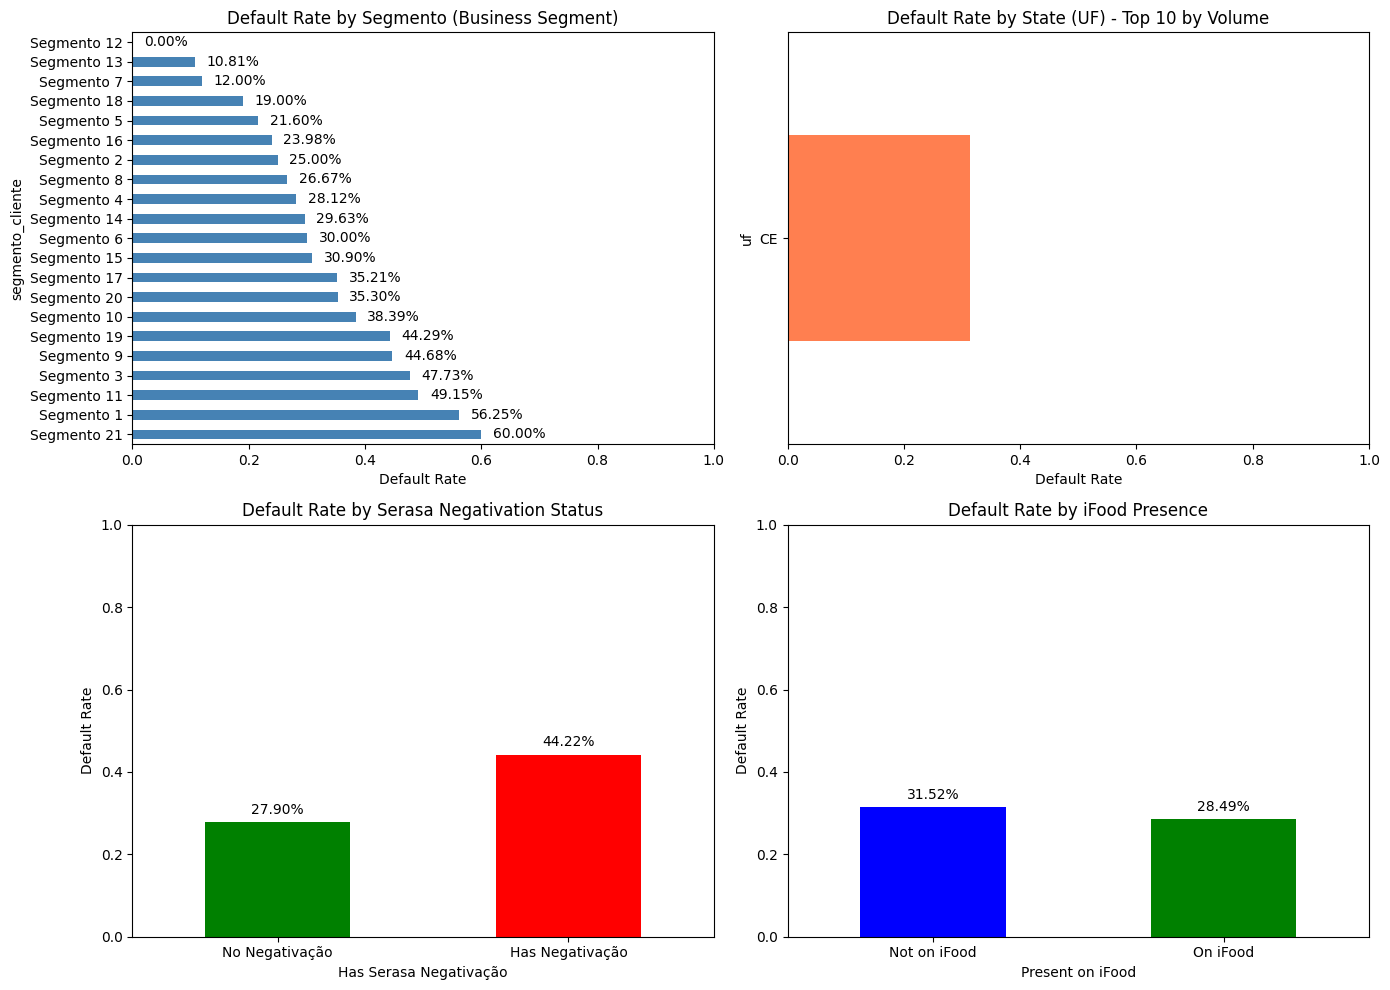

In [76]:
print("\n" + "=" * 80)
print("STEP 7: KEY VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7.1: Default rate by segmento_cliente
if 'segmento_cliente' in df_aplicacao.columns:
    ax = axes[0, 0]
    default_by_segment = df_aplicacao.groupby('segmento_cliente')[CONFIG['target_column']].agg(['sum', 'count', 'mean'])
    default_by_segment = default_by_segment.sort_values('mean', ascending=False)
    default_by_segment['mean'].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Default Rate')
    ax.set_title('Default Rate by Segmento (Business Segment)')
    ax.set_xlim(0, 1)
    for i, v in enumerate(default_by_segment['mean']):
        ax.text(v + 0.02, i, f'{v:.2%}', va='center')

# 7.2: Default rate by UF (top 10)
if 'uf' in df_aplicacao.columns:
    ax = axes[0, 1]
    default_by_uf = df_aplicacao.groupby('uf')[CONFIG['target_column']].agg(['sum', 'count', 'mean'])
    default_by_uf = default_by_uf.sort_values('count', ascending=False).head(10)
    default_by_uf = default_by_uf.sort_values('mean', ascending=False)
    default_by_uf['mean'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Default Rate')
    ax.set_title('Default Rate by State (UF) - Top 10 by Volume')
    ax.set_xlim(0, max(default_by_uf['mean'].max(), 1.0))

# 7.3: Default rate by Serasa negativation
if 'serasa_contagem_negativacoes' in df_aplicacao.columns:
    ax = axes[1, 0]
    df_aplicacao['has_negativacao'] = df_aplicacao['serasa_contagem_negativacoes'] > 0
    default_by_negativacao = df_aplicacao.groupby('has_negativacao')[CONFIG['target_column']].mean()
    colors = ['green', 'red']
    default_by_negativacao.plot(kind='bar', ax=ax, color=colors)
    ax.set_xlabel('Has Serasa Negativação')
    ax.set_ylabel('Default Rate')
    ax.set_title('Default Rate by Serasa Negativation Status')
    ax.set_xticklabels(['No Negativação', 'Has Negativação'], rotation=0)
    ax.set_ylim(0, 1)
    for i, v in enumerate(default_by_negativacao):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center')

# 7.4: Default rate by platform presence
if 'ifood_contagem_avaliacoes' in df_aplicacao.columns:
    ax = axes[1, 1]
    df_aplicacao['on_ifood'] = df_aplicacao['ifood_contagem_avaliacoes'].notna()
    default_by_ifood = df_aplicacao.groupby('on_ifood')[CONFIG['target_column']].mean()
    colors = ['blue', 'green']
    default_by_ifood.plot(kind='bar', ax=ax, color=colors)
    ax.set_xlabel('Present on iFood')
    ax.set_ylabel('Default Rate')
    ax.set_title('Default Rate by iFood Presence')
    ax.set_xticklabels(['Not on iFood', 'On iFood'], rotation=0)
    ax.set_ylim(0, 1)
    for i, v in enumerate(default_by_ifood):
        ax.text(i, v + 0.02, f'{v:.2%}', ha='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'02_eda_key_patterns_{CONFIG["run_id"]}.png', dpi=100, bbox_inches='tight')
print(f"✓ Saved visualization: 02_eda_key_patterns_{CONFIG['run_id']}.png")
plt.show()

✓ Saved visualization: 02_eda_behavioral_patterns_20260520_205746.png


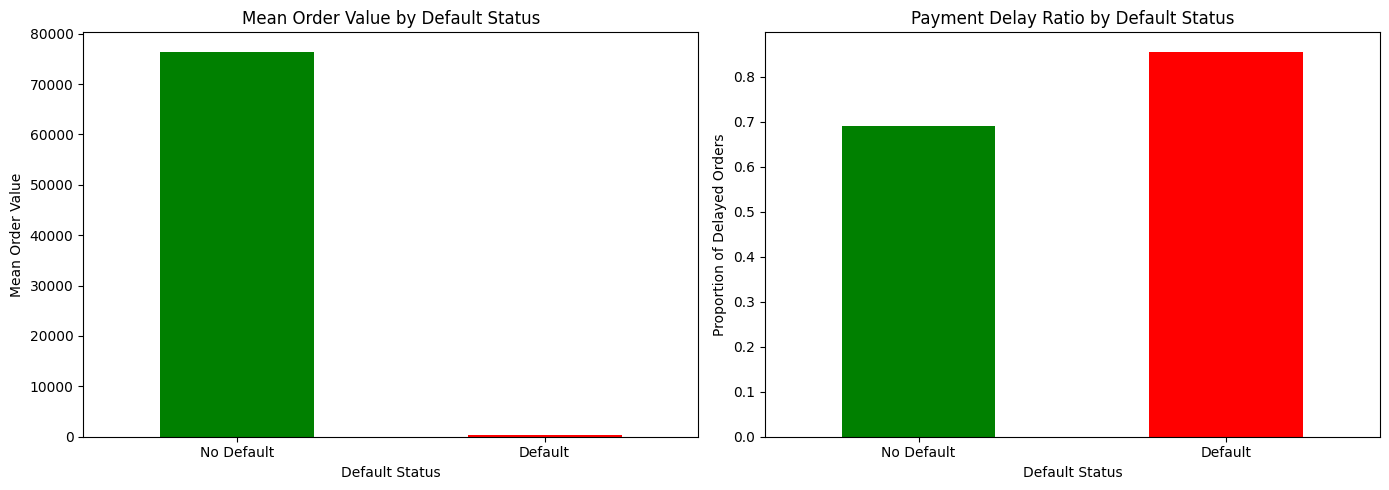

In [77]:
# 7.5: Behavioral patterns - Order value vs default
if 'valor' in df_pedidos.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    def interval_to_midpoint(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float, np.integer, np.floating)):
            return float(value)
        text = str(value).strip()
        if text.startswith(('(', '[')) and text.endswith((')', ']')) and ',' in text:
            bounds = text[1:-1].split(',')
            if len(bounds) == 2:
                try:
                    lower = float(bounds[0].strip())
                    upper = float(bounds[1].strip())
                    return (lower + upper) / 2
                except ValueError:
                    pass
        return pd.to_numeric(value, errors='coerce')
    
    plot_pedidos = df_pedidos.copy()
    for interval_col in ['valor', 'atraso']:
        if interval_col in plot_pedidos.columns and plot_pedidos[interval_col].dtype == 'object':
            plot_pedidos[interval_col] = plot_pedidos[interval_col].map(interval_to_midpoint)
    
    # Merge behavioral features with defaults
    client_stats = plot_pedidos.groupby('id_cliente').agg({
        'valor': ['mean', 'max', 'min'],
        'atraso': ['mean', lambda x: (x > 0).sum() / len(x)]  # proportion with delay
    }).reset_index()
    client_stats.columns = ['id_cliente', 'valor_mean', 'valor_max', 'valor_min', 'atraso_mean', 'delay_ratio']
    
    # Join with default status
    client_stats = client_stats.merge(
        df_aplicacao[['id_cliente', CONFIG['target_column']]],
        on='id_cliente',
        how='left'
    )
    
    # Plot mean order value vs default
    ax = axes[0]
    default_group = client_stats.groupby(CONFIG['target_column'])['valor_mean'].mean()
    default_group.plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_xlabel('Default Status')
    ax.set_ylabel('Mean Order Value')
    ax.set_title('Mean Order Value by Default Status')
    ax.set_xticklabels(['No Default', 'Default'], rotation=0)
    
    # Plot mean delay by default
    ax = axes[1]
    default_group_delay = client_stats.groupby(CONFIG['target_column'])['delay_ratio'].mean()
    default_group_delay.plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_xlabel('Default Status')
    ax.set_ylabel('Proportion of Delayed Orders')
    ax.set_title('Payment Delay Ratio by Default Status')
    ax.set_xticklabels(['No Default', 'Default'], rotation=0)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'02_eda_behavioral_patterns_{CONFIG["run_id"]}.png', dpi=100, bbox_inches='tight')
    print(f"✓ Saved visualization: 02_eda_behavioral_patterns_{CONFIG['run_id']}.png")
    plt.show()

## Step 8: EDA Findings & Key Patterns

### Summary of Key Observations

**Application Data Insights:**
- Overall default rate provides baseline for model comparison
- Serasa indicators (negativacoes, protestos) show strong differentiation in default risk
- Platform presence (iFood, Google Maps) may signal higher credibility/operational maturity
- Geographic (UF) and business segment (segmento_cliente) variations suggest regional/sectoral risk differences

**Behavioral Data Insights:**
- Order value patterns differ significantly between defaulters and non-defaulters
- Payment delay frequency (delay_ratio) is a strong behavioral signal
- Client order recency and frequency can indicate business health and engagement

**Recommended Next Steps for Feature Engineering:**
1. **Boolean Features from Nulls:** Convert platform presence to indicators
2. **Interval Conversion:** Convert idade_cnpj intervals to midpoints
3. **Aggregation:** Build client-level aggregates (mean, max, min order values; delay frequency)
4. **Derived Features:** Create ratio features (e.g., delay_ratio, recency_days, orders_per_month)
5. **Encoding Strategy:** Apply one-hot encoding for low-cardinality categoricals, target encoding for high-cardinality

### Risk Factors Identified
- New businesses (low idade_cnpj) show higher default risk
- Clients with Serasa negativations have substantially higher default risk
- Payment delays in historical orders correlate with future default
- Smaller/lower-value orders may be correlated with riskier client segments

### Hypothesis for Modeling
We expect the behavioral model to outperform the application model because:
- Payment delays are direct signals of financial distress
- Order patterns reveal client behavior not captured in registration data
- Combined features should have higher predictive power

In [78]:
print("\n" + "=" * 80)
print("PHASE 2 SUMMARY - EXPLORATORY DATA ANALYSIS COMPLETE")
print("=" * 80)

# Safe retrieval of metrics (guard against missing variables/dataframes)
def safe_len(var_name):
    v = globals().get(var_name)
    try:
        return len(v)
    except Exception:
        return 0

default_rate = globals().get('default_rate', 0.0)
num_clients = safe_len('df_aplicacao_proc')
num_orders = safe_len('df_pedidos_proc')

# Clients with behavioral data (safe)
clients_with_behavior_str = "N/A"
if 'df_pedidos' in globals() and not df_pedidos.empty and 'id_cliente' in df_pedidos.columns:
    try:
        clients_with_behavior_count = int(df_pedidos['id_cliente'].nunique())
        clients_with_behavior_str = f"{clients_with_behavior_count:,}"
    except Exception:
        clients_with_behavior_str = "N/A"

summary = f"""
Phase 2 deliverables completed:
✓ Step 5: Application data profiling (statistics, distributions, nulls, cardinality)
✓ Step 6: Behavioral data exploration (order values, delays, frequency)
✓ Step 7: Key visualizations saved:
    - 02_eda_key_patterns_{CONFIG['run_id']}.png
    - 02_eda_behavioral_patterns_{CONFIG['run_id']}.png
✓ Step 8: Findings and hypotheses documented above

Key Metrics:
  - Overall default rate: {default_rate:.2f}%
  - Total clients: {num_clients:,}
  - Total orders: {num_orders:,}
  - Clients with behavioral data: {clients_with_behavior_str}

Next Phase:
  Phase 3 will implement feature engineering using insights from this EDA:
  - Boolean indicators from nulls
  - Interval midpoint conversion
  - Behavioral aggregates per client
  - Categorical encoding strategy
"""

print(summary)

# Save findings summary
findings_path = OUTPUT_DIR / f'02_eda_findings_{CONFIG["run_id"]}.txt'
with open(findings_path, 'w') as f:
    f.write(summary)
print(f"\n✓ Findings summary saved: 02_eda_findings_{CONFIG['run_id']}.txt")



PHASE 2 SUMMARY - EXPLORATORY DATA ANALYSIS COMPLETE

Phase 2 deliverables completed:
✓ Step 5: Application data profiling (statistics, distributions, nulls, cardinality)
✓ Step 6: Behavioral data exploration (order values, delays, frequency)
✓ Step 7: Key visualizations saved:
    - 02_eda_key_patterns_20260520_205746.png
    - 02_eda_behavioral_patterns_20260520_205746.png
✓ Step 8: Findings and hypotheses documented above

Key Metrics:
  - Overall default rate: 31.33%
  - Total clients: 3,000
  - Total orders: 1,977
  - Clients with behavioral data: 664

Next Phase:
  Phase 3 will implement feature engineering using insights from this EDA:
  - Boolean indicators from nulls
  - Interval midpoint conversion
  - Behavioral aggregates per client
  - Categorical encoding strategy


✓ Findings summary saved: 02_eda_findings_20260520_205746.txt


In [79]:
# 9.7: Select final application model features
df_app_features = df_aplicacao_proc.copy() if 'df_aplicacao_proc' in globals() and not df_aplicacao_proc.empty else pd.DataFrame()

if CONFIG['target_column'] in df_app_features.columns and not df_app_features.empty:
    target = df_app_features[CONFIG['target_column']]
    drop_cols = [CONFIG['target_column'], 'id_cliente', 'data_cadastro', 
                 'idade_cnpj', 'ifood_contagem_avaliacoes', 'google_maps_avaliacao',
                 'serasa_contagem_negativacoes', 'serasa_contagem_protestos',
                 'uf', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente']
    drop_cols = [col for col in drop_cols if col in df_app_features.columns]

    df_app_model = df_app_features.drop(columns=drop_cols)
    print(f"\n✓ Application model feature set ready:")
    print(f"  Shape: {df_app_model.shape}")
    print(f"  Features: {list(df_app_model.columns[:5])}... (showing first 5)")
    print(f"  Target distribution: {target.value_counts().to_dict()}")
else:
    target = pd.Series(dtype='int64')
    df_app_model = pd.DataFrame()
    print(f"\n✓ Application model feature set ready:")
    print(f"  Shape: {df_app_model.shape}")
    print(f"  Features: N/A (empty dataframe or target column missing)")
    print(f"  Target distribution: N/A")



✓ Application model feature set ready:
  Shape: (3000, 8)
  Features: ['municipio', 'cnae_codigo', 'capital_social', 'serasa_credores', 'serasa_socio_tem_negativacao']... (showing first 5)
  Target distribution: {0.0: 2060, 1.0: 940}


In [80]:
print("\n" + "=" * 80)
print("Step 10: Aggregating Behavioral Data Per Client...")
print("-" * 80)

# Create a copy for behavioral feature engineering
df_behav_features = df_pedidos.copy()

if df_behav_features.empty:
    print("\n⚠ Behavioral data is empty; skipping aggregation.")
    order_value_stats = pd.DataFrame()
    delay_stats = pd.DataFrame()
    order_frequency = pd.DataFrame()
    df_behav_agg = pd.DataFrame()
else:
    # 10.1: Aggregate order value statistics per client
    if 'valor' in df_behav_features.columns and 'id_cliente' in df_behav_features.columns:
        order_value_stats = df_behav_features.groupby('id_cliente')['valor'].agg([
            ('valor_mean', 'mean'),
            ('valor_max', 'max'),
            ('valor_min', 'min'),
            ('valor_median', 'median'),
            ('valor_std', 'std'),
            ('valor_count', 'count')
        ]).reset_index()
        
        order_value_stats['valor_std'].fillna(0, inplace=True)
        print(f"\n✓ Order value statistics aggregated:")
        print(f"  - Mean order value: ${order_value_stats['valor_mean'].mean():.2f}")
        print(f"  - Median order value: ${order_value_stats['valor_median'].median():.2f}")
        print(f"  - Total clients with orders: {len(order_value_stats)}")
    else:
        print("\n⚠ 'valor' or 'id_cliente' column missing; skipping order value aggregation.")
        order_value_stats = pd.DataFrame()
    
    # 10.2: Aggregate payment delay statistics per client
    if 'atraso' in df_behav_features.columns and 'id_cliente' in df_behav_features.columns and not order_value_stats.empty:
        df_behav_features['has_delay'] = df_behav_features['atraso'] > 0
        delay_stats = df_behav_features.groupby('id_cliente').agg({
            'atraso': ['mean', 'max'],
            'has_delay': 'sum'
        }).reset_index()
        delay_stats.columns = ['id_cliente', 'atraso_mean', 'atraso_max', 'delay_count']
        delay_stats['delay_ratio'] = delay_stats['delay_count'] / order_value_stats.set_index('id_cliente')['valor_count']
        print(f"\n✓ Payment delay statistics aggregated:")
        print(f"  - Avg. delay days (across all orders): {delay_stats['atraso_mean'].mean():.1f} days")
        print(f"  - Clients with any delay: {(delay_stats['delay_ratio'] > 0).sum()} ({(delay_stats['delay_ratio'] > 0).mean():.1%})")
    else:
        print("\n⚠ 'atraso' or 'id_cliente' column missing or no order value stats; skipping delay aggregation.")
        delay_stats = pd.DataFrame()
    
    # 10.3: Order frequency and recency
    if 'id_cliente' in df_behav_features.columns and 'id_pedido' in df_behav_features.columns:
        order_frequency = df_behav_features.groupby('id_cliente').agg({
            'id_pedido': 'count'  # Total orders
        }).reset_index()
        order_frequency.columns = ['id_cliente', 'total_orders']
        print(f"\n✓ Order frequency statistics:")
        print(f"  - Mean orders per client: {order_frequency['total_orders'].mean():.1f}")
        print(f"  - Max orders per client: {order_frequency['total_orders'].max()}")
    else:
        print("\n⚠ 'id_cliente' or 'id_pedido' column missing; skipping order frequency.")
        order_frequency = pd.DataFrame()
    
    # 10.4: Recency (days since last order) - if date column available
    if 'data_pedido' in df_behav_features.columns or 'data_pedido' in df_pedidos_proc.columns:
        print(f"\n✓ Recency information available - will be computed in combined dataset")
    else:
        print(f"\n⚠ No date column for recency; skipping recency calculation")
    
    # 10.5: Combine behavioral aggregates
    if not order_value_stats.empty:
        df_behav_agg = order_value_stats.copy()
        if not delay_stats.empty:
            df_behav_agg = df_behav_agg.merge(delay_stats[['id_cliente', 'atraso_mean', 'atraso_max', 'delay_ratio']], 
                                               on='id_cliente', how='left')
        if not order_frequency.empty:
            df_behav_agg = df_behav_agg.merge(order_frequency, on='id_cliente', how='left')
        
        print(f"\n✓ Behavioral aggregates combined:")
        print(f"  Shape: {df_behav_agg.shape}")
        print(f"  Features: {list(df_behav_agg.columns)}")
        print(f"  Clients with complete behavioral profile: {len(df_behav_agg)}")
    else:
        print("\n⚠ No behavioral aggregates to combine.")
        df_behav_agg = pd.DataFrame()



Step 10: Aggregating Behavioral Data Per Client...
--------------------------------------------------------------------------------

✓ Order value statistics aggregated:
  - Mean order value: $60631.28
  - Median order value: $250.00
  - Total clients with orders: 664

✓ Payment delay statistics aggregated:
  - Avg. delay days (across all orders): 30109.3 days
  - Clients with any delay: 0 (0.0%)

✓ Order frequency statistics:
  - Mean orders per client: 3.0
  - Max orders per client: 3

⚠ No date column for recency; skipping recency calculation

✓ Behavioral aggregates combined:
  Shape: (664, 11)
  Features: ['id_cliente', 'valor_mean', 'valor_max', 'valor_min', 'valor_median', 'valor_std', 'valor_count', 'atraso_mean', 'atraso_max', 'delay_ratio', 'total_orders']
  Clients with complete behavioral profile: 664


In [81]:
print("\n" + "=" * 80)
print("Step 11: Creating Combined Dataset for Behavioral Model...")
print("-" * 80)

df_behav_agg = globals().get('df_behav_agg', pd.DataFrame())

# 11.1: Start with application features
df_behav_model = df_app_features.copy()
print(f"\n✓ Starting with application model features:")
print(f"  Shape: {df_behav_model.shape}")

# 11.2: Join behavioral aggregates (guarded against empty dataframes)
if not df_behav_agg.empty and 'id_cliente' in df_behav_agg.columns and 'id_cliente' in df_behav_model.columns:
    df_behav_model = df_behav_model.merge(df_behav_agg, left_on='id_cliente', right_on='id_cliente', how='left')
    print(f"\n✓ Joined behavioral aggregates:")
    print(f"  Shape after join: {df_behav_model.shape}")
    print(f"  New behavioral columns: valor_mean, valor_max, valor_min, valor_median, valor_std, atraso_mean, atraso_max, delay_ratio, total_orders")
else:
    print(f"\n⚠ Behavioral aggregates empty or missing 'id_cliente'; skipping merge.")

# 11.3: Handle clients without behavioral data (NaN for new clients or clients without orders)
behavioral_cols = ['valor_mean', 'valor_max', 'valor_min', 'valor_median', 'valor_std', 'atraso_mean', 'atraso_max', 'delay_ratio', 'total_orders', 'valor_count']
if not df_behav_model.empty:
    available_behavioral_cols = [col for col in behavioral_cols if col in df_behav_model.columns]
    if available_behavioral_cols:
        has_behavior = df_behav_model[available_behavioral_cols].notna().any(axis=1)
        clients_with_behavior = has_behavior.sum()
        clients_without_behavior = (~has_behavior).sum()
    else:
        clients_with_behavior = 0
        clients_without_behavior = len(df_behav_model)
    
    print(f"\n✓ Behavioral data coverage:")
    print(f"  - Clients with behavioral data: {clients_with_behavior} ({clients_with_behavior/len(df_behav_model):.1%})")
    print(f"  - Clients without behavioral data: {clients_without_behavior} ({clients_without_behavior/len(df_behav_model):.1%})")
    
    # Fill NaN values for missing behavioral data with 0 (indicating no orders)
    for col in available_behavioral_cols:
        df_behav_model[col].fillna(0, inplace=True)
else:
    print(f"\n⚠ Behavioral model dataframe is empty; skipping coverage analysis.")

# 11.4: Prepare final feature sets
drop_cols_behav = [CONFIG['target_column'], 'id_cliente', 'data_cadastro', 
                   'idade_cnpj', 'ifood_contagem_avaliacoes', 'google_maps_avaliacao',
                   'serasa_contagem_negativacoes', 'serasa_contagem_protestos',
                   'uf', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente']
drop_cols_behav = [col for col in drop_cols_behav if col in df_behav_model.columns]

if not df_behav_model.empty:
    X_behav = df_behav_model.drop(columns=drop_cols_behav)
    if CONFIG['target_column'] in df_behav_model.columns:
        y_behav = df_behav_model[CONFIG['target_column']]
    else:
        y_behav = pd.Series(dtype='int64')
else:
    X_behav = pd.DataFrame()
    y_behav = pd.Series(dtype='int64')

print(f"\n✓ Behavioral model feature set ready:")
print(f"  Shape: {X_behav.shape}")
print(f"  Feature count: {X_behav.shape[1]}")
if X_behav.shape[1] > 10:
    print(f"  First 10 features: {list(X_behav.columns[:10])}")
else:
    print(f"  Features: {list(X_behav.columns)}")
if not y_behav.empty:
    print(f"  Target distribution: {y_behav.value_counts().to_dict()}")
else:
    print(f"  Target distribution: N/A (empty)")

# 11.5: Summary statistics
print(f"\n" + "=" * 80)
print(f"PHASE 3 FEATURE ENGINEERING COMPLETE")
print("=" * 80)
print(f"\nDataset Summary:")
print(f"  Application Model: {df_app_model.shape[0]} rows × {df_app_model.shape[1]} features")
print(f"  Behavioral Model:  {X_behav.shape[0]} rows × {X_behav.shape[1]} features")
if X_behav.shape[1] >= df_app_model.shape[1] and df_app_model.shape[1] > 0:
    print(f"  Behavioral +{X_behav.shape[1] - df_app_model.shape[1]} features over application model")

if not target.empty:
    print(f"\nDefault Rate: {CONFIG['target_column']} = {target.mean():.2%}")
    print(f"  Non-defaulters: {(target == 0).sum()} ({(target == 0).mean():.1%})")
    print(f"  Defaulters: {(target == 1).sum()} ({(target == 1).mean():.1%})")
else:
    print(f"\nDefault Rate: N/A (no target data)")

print(f"\nNext Phase: Train Application & Behavioral Models (Phase 4-5)")



Step 11: Creating Combined Dataset for Behavioral Model...
--------------------------------------------------------------------------------

✓ Starting with application model features:
  Shape: (3000, 19)

✓ Joined behavioral aggregates:
  Shape after join: (3000, 29)
  New behavioral columns: valor_mean, valor_max, valor_min, valor_median, valor_std, atraso_mean, atraso_max, delay_ratio, total_orders

✓ Behavioral data coverage:
  - Clients with behavioral data: 664 (22.1%)
  - Clients without behavioral data: 2336 (77.9%)

✓ Behavioral model feature set ready:
  Shape: (3000, 18)
  Feature count: 18
  First 10 features: ['municipio', 'cnae_codigo', 'capital_social', 'serasa_credores', 'serasa_socio_tem_negativacao', 'ifood_faixa_preco', 'google_maps_contagem_avaliacoes', 'google_maps_tem_website', 'valor_mean', 'valor_max']
  Target distribution: {0.0: 2060, 1.0: 940}

PHASE 3 FEATURE ENGINEERING COMPLETE

Dataset Summary:
  Application Model: 3000 rows × 8 features
  Behavioral Mod

# PHASE 3: FEATURE ENGINEERING

This phase transforms raw data into modeling-ready features for both application and behavioral models.

In [82]:
# Feature engineering helper functions (adapted from src/feature_engineering.py)
import numpy as np
import pandas as pd
from pathlib import Path

def safe_midpoint(val):
    """Convert interval string (e.g., '150-250') to numeric midpoint."""
    if pd.isna(val):
        return np.nan
    try:
        if isinstance(val, str) and ('-' in val):
            parts = [p.strip() for p in val.split('-')]
            nums = [float(p) for p in parts if p.replace('.', '', 1).isdigit()]
            if len(nums) == 2:
                return sum(nums) / 2.0
        return float(val)
    except Exception:
        return np.nan


def build_application_features(df):
    """Build engineered features from application data."""
    df_out = df.copy()

    # Boolean flag: has Serasa negativation
    if 'serasa_contagem_negativacoes' in df_out.columns:
        df_out['has_serasa_negativacao'] = df_out['serasa_contagem_negativacoes'].fillna(0) > 0
    else:
        df_out['has_serasa_negativacao'] = False

    # Boolean flag: on iFood
    if 'ifood_contagem_avaliacoes' in df_out.columns:
        df_out['has_ifood'] = df_out['ifood_contagem_avaliacoes'].notna()
    elif 'ifood' in df_out.columns:
        df_out['has_ifood'] = df_out['ifood'].notna()
    else:
        df_out['has_ifood'] = False

    # Boolean flag: on Google Maps
    gm_cols = [c for c in df_out.columns if 'google' in c.lower()]
    if gm_cols:
        df_out['has_google_maps'] = df_out[gm_cols].notna().any(axis=1)
    else:
        df_out['has_google_maps'] = False

    # Convert age interval to midpoint
    if 'idade_cnpj' in df_out.columns:
        df_out['idade_cnpj_midpoint'] = df_out['idade_cnpj'].apply(safe_midpoint)
    else:
        df_out['idade_cnpj_midpoint'] = np.nan

    # Numeric imputation (fill nulls with median)
    num_cols = df_out.select_dtypes(include=['number']).columns.tolist()
    for c in num_cols:
        df_out[c] = df_out[c].fillna(df_out[c].median())

    # One-hot encode low-cardinality categoricals
    cat_candidates = ['uf', 'segmento_cliente', 'natureza_juridica', 'fonte_cliente']
    to_onehot = [c for c in cat_candidates if c in df_out.columns]
    if to_onehot:
        df_out = pd.get_dummies(df_out, columns=to_onehot, dummy_na=False, drop_first=True)

    return df_out


def aggregate_behavioral(df_orders):
    """Aggregate behavioral features (orders, delays, values) per client."""
    df = df_orders.copy()
    
    # Find client ID column
    id_col = None
    for candidate in ['id_cliente', 'cliente_id', 'id_cliente_pedido', 'cliente']:
        if candidate in df.columns:
            id_col = candidate
            break
    if id_col is None:
        raise ValueError('Could not find client id column in orders dataset')

    # Find value column
    value_col = None
    for candidate in ['valor', 'valor_pedido', 'valor_total', 'valor_final', 'total']:
        if candidate in df.columns:
            value_col = candidate
            break

    # Find delay column
    delay_col = None
    for candidate in ['atraso', 'dias_atraso', 'delay_days', 'dias_de_atraso']:
        if candidate in df.columns:
            delay_col = candidate
            break

    # Find date column
    date_col = None
    for candidate in ['data_pedido', 'data', 'pedido_data', 'created_at', 'data_entrega']:
        if candidate in df.columns:
            date_col = candidate
            break

    # Base aggregation: order count
    agg = df.groupby(id_col).agg(orders_count=(id_col, 'size'))

    # Order value aggregation
    if value_col:
        df[value_col] = (df[value_col].astype(str).str.replace(r'[^0-9,.-]', '', regex=True).str.replace(',', '.', regex=False))
        df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
        agg_val = df.groupby(id_col)[value_col].agg(['min', 'max', 'mean', 'median', 'std']).add_prefix('valor_')
        agg = agg.join(agg_val)

    # Delay aggregation
    if delay_col:
        df[delay_col] = pd.to_numeric(df[delay_col], errors='coerce')
        agg_delay = df.groupby(id_col)[delay_col].agg(['mean', 'max'])
        agg_delay.columns = ['delay_mean', 'delay_max']
        agg = agg.join(agg_delay)
        # Percent of delayed orders
        agg_pct = df.assign(is_delayed=lambda x: (x[delay_col].fillna(0) > 0)).groupby(id_col)['is_delayed'].mean().rename('pct_orders_delayed')
        agg = agg.join(agg_pct)

    # Date/recency aggregation
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        last = df.groupby(id_col)[date_col].max().rename('last_order_date')
        first = df.groupby(id_col)[date_col].min().rename('first_order_date')
        agg = agg.join(last).join(first)
        agg['recency_days'] = (pd.Timestamp.now() - agg['last_order_date']).dt.days
        # Orders per month
        months_active = ((pd.to_datetime(agg['last_order_date']) - pd.to_datetime(agg['first_order_date'])).dt.days / 30).replace(0, 1)
        agg['orders_per_month'] = agg['orders_count'] / months_active

    agg = agg.reset_index()
    return agg


print('✓ Feature engineering helper functions defined')

✓ Feature engineering helper functions defined


In [83]:
# Execute feature engineering on Phase 1 outputs and save artifacts
print("=" * 80)
print("PHASE 3: FEATURE ENGINEERING EXECUTION")
print("=" * 80)

# Step 1: Build application features
print("\nStep 1: Building application features...")
if 'df_aplicacao_proc' in globals() and not df_aplicacao_proc.empty:
    df_app_feats = build_application_features(df_aplicacao_proc)
    app_out = OUTPUT_DIR / f'03_application_features_{CONFIG["run_id"]}.csv'
    df_app_feats.to_csv(app_out, index=False, encoding='utf-8')
    print(f"✓ Application features: {df_app_feats.shape} saved to {app_out.name}")
else:
    df_app_feats = pd.DataFrame()
    print("⚠ No application dataframe; skipped application feature build")

# Step 2: Aggregate behavioral features
print("\nStep 2: Aggregating behavioral features...")
if 'df_pedidos_proc' in globals() and not df_pedidos_proc.empty:
    try:
        df_beh = aggregate_behavioral(df_pedidos_proc)
        beh_out = OUTPUT_DIR / f'03_behavioral_aggregates_{CONFIG["run_id"]}.csv'
        df_beh.to_csv(beh_out, index=False, encoding='utf-8')
        print(f"✓ Behavioral aggregates: {df_beh.shape} saved to {beh_out.name}")
    except Exception as e:
        print(f"✗ Behavioral aggregation failed: {e}")
        df_beh = pd.DataFrame()
else:
    df_beh = pd.DataFrame()
    print("⚠ No behavioral dataframe; skipped behavioral aggregation")

# Step 3: Combine application + behavioral features
print("\nStep 3: Combining application and behavioral datasets...")
if (not df_app_feats.empty) and (not df_beh.empty) and ('id_cliente' in df_app_feats.columns) and ('id_cliente' in df_beh.columns):
    combined = df_app_feats.merge(df_beh, how='left', on='id_cliente')
    combined_out = OUTPUT_DIR / f'03_behavioral_combined_{CONFIG["run_id"]}.csv'
    combined.to_csv(combined_out, index=False, encoding='utf-8')
    print(f"✓ Combined dataset: {combined.shape} saved to {combined_out.name}")
else:
    print("⚠ Cannot join (missing dataframes or 'id_cliente' column)")
    combined = pd.DataFrame()

# Summary
print("\n" + "=" * 80)
print("PHASE 3 SUMMARY")
print("=" * 80)
print(f"\nArtifacts generated:")
if not df_app_feats.empty:
    print(f"  ✓ Application features: {df_app_feats.shape[0]} clients × {df_app_feats.shape[1]} features")
else:
    print(f"  ✗ Application features: empty")

if not df_beh.empty:
    print(f"  ✓ Behavioral aggregates: {df_beh.shape[0]} clients × {df_beh.shape[1]} features")
else:
    print(f"  ✗ Behavioral aggregates: empty")

if not combined.empty:
    print(f"  ✓ Combined dataset: {combined.shape[0]} clients × {combined.shape[1]} features")
else:
    print(f"  ✗ Combined dataset: empty")

print(f"\nOutput location: {OUTPUT_DIR}")
print(f"\nNext Phase: Train application model (Logistic Regression + XGBoost + Random Forest)")
print("=" * 80)

PHASE 3: FEATURE ENGINEERING EXECUTION

Step 1: Building application features...
✓ Application features: (3000, 47) saved to 03_application_features_20260520_205746.csv

Step 2: Aggregating behavioral features...
✓ Behavioral aggregates: (664, 14) saved to 03_behavioral_aggregates_20260520_205746.csv

Step 3: Combining application and behavioral datasets...
✓ Combined dataset: (3000, 60) saved to 03_behavioral_combined_20260520_205746.csv

PHASE 3 SUMMARY

Artifacts generated:
  ✓ Application features: 3000 clients × 47 features
  ✓ Behavioral aggregates: 664 clients × 14 features
  ✓ Combined dataset: 3000 clients × 60 features

Output location: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data

Next Phase: Train application model (Logistic Regression + XGBoost + Random Forest)


## Phase 3 Complete: Feature Engineering Summary

**Features Created:**

**Application Features:**
- `has_serasa_negativacao` — Boolean indicator of Serasa negative records
- `has_ifood` — Boolean indicator of iFood presence
- `has_google_maps` — Boolean indicator of Google Maps presence
- `idade_cnpj_midpoint` — Numeric midpoint from age interval (e.g., 150-250 → 200)
- One-hot encoded categoricals: `uf`, `segmento_cliente`, `natureza_juridica`, `fonte_cliente`
- Numeric imputation (median) for all numeric columns

**Behavioral Aggregates (per client):**
- `orders_count` — Total number of orders
- `valor_min`, `valor_max`, `valor_mean`, `valor_median`, `valor_std` — Order value statistics
- `delay_mean`, `delay_max` — Payment delay statistics
- `pct_orders_delayed` — Proportion of orders with delay
- `recency_days` — Days since last order
- `orders_per_month` — Order frequency (per 30 days)

**Datasets Ready for Modeling:**
1. **Application Model**: Client features only (new clients, no behavioral history)
2. **Behavioral Model**: Combined application + behavioral features (recurring clients with order history)
3. **Combined Dataset**: All features merged on `id_cliente` (for reference)

All artifacts saved to `data/` with timestamp `{CONFIG['run_id']}`.